# 01 Baseline Network

Build the Marshfield Baseline Network using the SHIFT → GDM → DiTTo pipeline and export
the canonical Asset Registry

**Prerequisite for flood notebooks:** `01_region_setup.ipynb` reads from `grid.asset_registry`
produced here. Run this notebook first.

> **Stage Contract**
>
> Requires: location config, grid source area, reviewed source anchors, OSM building parcels
>
> Produces: OpenDSS base model, asset registry, augmented grid seed artifacts
>
> Next: 02_augment_network/01_der_inventory.ipynb

## Runtime

In [1]:
import json
import math
import pickle
import tempfile
from pathlib import Path
import sys

import pandas as pd
from IPython.display import display

location_root = Path("..").resolve()
repo_root = location_root.parents[1]
src_root = repo_root / "src"
sys.path.insert(0, str(src_root))

# load Location Workspace config and standard grid paths.
from power.notebook import load_runtime

runtime = load_runtime(location_root)
location_root = runtime.location_root
location_name = runtime.location_name
repo_root = runtime.repo_root
config = runtime.config
paths = runtime.paths
grid = runtime.grid


asset_registry: /home/grahamhults/projects/Flood-RM/locations/marshfield/data/power_grid/asset_registry
opendss_root: /home/grahamhults/projects/Flood-RM/locations/marshfield/data/power_grid/derived_opendss


## Rerun Control


In [ ]:
rerun = False


## Fetch Parcels

Resolve the configured grid source area, fetch OSM building parcels, and cache the
parcel payload to `grid.shift_cache` so the SHIFT build can be re-run without re-downloading.
`grid.shift_cache` so the SHIFT build can be re-run without re-downloading.

In [2]:
# resolve study area, source anchors, and parcel inputs.
from power.baseline_network.source_inputs import source_area
# supply building footprints for SHIFT load placement.
from power.baseline_network.source_inputs import fetch_parcels

tile_size_deg = 0.015
customers_per_transformer = 15
min_parcels_per_tile = 5
inputs_cache_path = grid["shift_cache"] / "inputs_parcels.pkl"

if inputs_cache_path.exists() and not rerun:
    with inputs_cache_path.open("rb") as f:
        cached = pickle.load(f)
    study_area = cached["study_area"]
    study_polygons = cached.get("study_polygons") or (list(study_area.geoms) if study_area.geom_type == "MultiPolygon" else [study_area])
    bounds = cached.get("bounds", study_area.bounds)
    parcels = cached["parcels"]
    print(f"Loaded {len(parcels)} parcels from cache.")
else:
    grid_source_area = source_area(config)
    study_area = grid_source_area.geometry
    study_polygons = list(study_area.geoms) if study_area.geom_type == "MultiPolygon" else [study_area]
    bounds = study_area.bounds
    # study_area already covers the union of geocoded place boundary + configured patches;
    # convex_hull guards the rare case where the union is a MultiPolygon.
    _fetch_geom = study_area if study_area.geom_type == "Polygon" else study_area.convex_hull
    parcels = fetch_parcels(_fetch_geom)
    with inputs_cache_path.open("wb") as f:
        pickle.dump({"source_area_place_name": grid_source_area.place_name, "source_area_patches": grid_source_area.patch_names, "study_area": study_area, "study_polygons": study_polygons, "bounds": bounds, "parcels": parcels}, f)
    print(f"Fetched and cached {len(parcels)} parcels.")

print(f"Using {len(parcels)} parcels across {len(study_polygons)} polygon(s).")


Loaded 13604 parcels from cache.
Using 13604 parcels across 1 polygon(s).


## Build Tiled Distribution Graphs

Tile the study area and run SHIFT's `PRSG` once per populated tile. Reviewed
Grid Source Anchors replace synthetic extent anchors. Each tile
produces one OpenDSS `Circuit`/`Vsource` for PowerModelsONM compatibility.

The tiled graph pickle is cached to `grid.shift_cache` to avoid full rebuilds.

In [3]:
from shift import (
    get_kmeans_clusters,
    PRSG,
    DistributionGraph,
    DistributionSystemBuilder,
    GeoLocation,
)
from shift.exceptions import EmptyGraphError
from gdm.distribution.components import DistributionTransformer
# resolve study area, source anchors, and parcel inputs.
from power.baseline_network.source_inputs import SourceAnchorReviewRequired, source_anchors

graphs_cache_path = grid["shift_cache"] / "tiled_distribution_graphs.pkl"
try:
    anchors = source_anchors(
        config,
        location_root=location_root,
        source_area_geometry=study_area,
    )
except SourceAnchorReviewRequired as exc:
    raise RuntimeError(str(exc)) from exc

def parcel_point(parcel):
    return parcel.geometry[0] if isinstance(parcel.geometry, list) else parcel.geometry

def haversine(lon1, lat1, lon2, lat2):
    dlat = math.radians(lat2 - lat1)
    dlon = math.radians(lon2 - lon1)
    a = math.sin(dlat / 2) ** 2 + math.cos(math.radians(lat1)) * math.cos(math.radians(lat2)) * math.sin(dlon / 2) ** 2
    return 12_742_000 * math.atan2(math.sqrt(a), math.sqrt(1 - a))

if not anchors:
    raise RuntimeError("No usable Grid Source Anchors were resolved.")

graph_cache_params = {
    "tile_size_deg": tile_size_deg,
    "customers_per_transformer": customers_per_transformer,
    "min_parcels_per_tile": min_parcels_per_tile,
    "parcel_count": len(parcels),
    "bounds": tuple(round(value, 8) for value in bounds),
    "source_anchor_policy": config["grid"]["source_anchors"]["source"],
    "source_anchor_ids": tuple(anchor["substation_id"] for anchor in anchors),
    "source_anchor_coords": tuple((round(anchor["lon"], 6), round(anchor["lat"], 6)) for anchor in anchors),
}

cached_graph_payload = None
if graphs_cache_path.exists() and not rerun:
    with graphs_cache_path.open("rb") as f:
        payload = pickle.load(f)
    if isinstance(payload, dict) and payload.get("params") == graph_cache_params:
        cached_graph_payload = payload
    else:
        print("Ignoring cached graphs because tile/build parameters changed.")

if cached_graph_payload is not None:
    anchors = cached_graph_payload["anchors"]
    tiles = cached_graph_payload["tiles"]
    active_tiles = cached_graph_payload["active_tiles"]
    graphs = cached_graph_payload["graphs"]
    skipped_tiles = cached_graph_payload["skipped_tiles"]
    source_assignments = cached_graph_payload.get("source_assignments", {})
    print(f"Loaded {len(graphs)} tiled graphs from cache.")
else:
    tiles = {}
    for parcel in parcels:
        point = parcel_point(parcel)
        key = (int((point.longitude - bounds[0]) / tile_size_deg), int((point.latitude - bounds[1]) / tile_size_deg))
        tiles.setdefault(key, []).append(parcel)
    active_tiles = {key: value for key, value in tiles.items() if len(value) >= min_parcels_per_tile}

    graphs, skipped_tiles, source_assignments = {}, {}, {}
    for idx, key in enumerate(sorted(active_tiles)):
        tile_parcels = active_tiles[key]
        pts = [parcel_point(parcel) for parcel in tile_parcels]
        cx = sum(point.longitude for point in pts) / len(pts)
        cy = sum(point.latitude for point in pts) / len(pts)
        source = min(anchors, key=lambda anchor: haversine(cx, cy, anchor["lon"], anchor["lat"]))
        clusters = get_kmeans_clusters(max(len(pts) // customers_per_transformer, 1), pts)
        try:
            graphs[idx] = PRSG(groups=clusters, source_location=GeoLocation(source["lon"], source["lat"])).get_distribution_graph()
            source_assignments[idx] = {
                "nearest_substation_id": source["substation_id"],
                "nearest_substation_name": source["name"],
            }
        except EmptyGraphError as exc:
            skipped_tiles[idx] = {"tile": key, "parcels": len(tile_parcels), "reason": str(exc)}
    with graphs_cache_path.open("wb") as f:
        pickle.dump(
            {
                "params": graph_cache_params,
                "anchors": anchors,
                "tiles": tiles,
                "active_tiles": active_tiles,
                "graphs": graphs,
                "skipped_tiles": skipped_tiles,
                "source_assignments": source_assignments,
            },
            f,
    )
    print(f"Built and cached {len(graphs)} tiled graphs.")

print(f"Built {len(graphs)} graphs; skipped {len(skipped_tiles)} empty tile(s).")
for anchor in anchors:
    print(f"  {anchor['name']}: reviewed Grid Source Anchor")


Loaded 44 tiled graphs from cache.
Built 44 graphs; skipped 1 empty tile(s).
 Marshfield Substation: MHMP substation source-area anchor
 Eversource Sub Station #1: MHMP substation source-area anchor
 Eversource Sub Station #2: MHMP substation source-area anchor
 Eversource Sub Station LAT: MHMP substation source-area anchor


## Update Branch Types

In [4]:
from gdm.distribution.components import DistributionBranchBase, MatrixImpedanceBranch

# Replace abstract DistributionBranchBase edges with MatrixImpedanceBranch
# so DiTTo can write line impedance data to OpenDSS.
new_graphs = {}
for idx, graph in graphs.items():
    g = DistributionGraph()
    for node in graph.get_nodes():
        g.add_node(node)
    for from_node, to_node, edge in graph.get_edges():
        if edge.edge_type == DistributionBranchBase:
            edge.edge_type = MatrixImpedanceBranch
        g.add_edge(from_node, to_node, edge_data=edge)
    new_graphs[idx] = g
print(f"Updated branch types for {len(new_graphs)} graphs.")


Updated branch types for 44 graphs.


## Map Phases

In [5]:
from shift import (
    BalancedPhaseMapper,
    TransformerPhaseMapperModel,
    TransformerTypes,
)
from gdm.distribution.components import DistributionTransformer
from gdm.quantities import ApparentPower

phase_mappers = {}
for idx, graph in new_graphs.items():
    transformer_models = [
        TransformerPhaseMapperModel(
            tr_name=edge.name,
            tr_type=TransformerTypes.SPLIT_PHASE,
            tr_capacity=ApparentPower(25, "kilovolt_ampere"),
            location=graph.get_node(from_node).location,
        )
        for from_node, _, edge in graph.get_edges()
        if edge.edge_type is DistributionTransformer
    ]
    phase_mappers[idx] = BalancedPhaseMapper(graph, mapper=transformer_models, method="greedy")
print(f"Mapped phases for {len(phase_mappers)} graphs.")


Mapped phases for 44 graphs.


## Map Voltages

In [6]:
from shift import TransformerVoltageMapper, TransformerVoltageModel
from gdm.quantities import Voltage

voltage_mappers = {}
for idx, graph in new_graphs.items():
    voltage_mappers[idx] = TransformerVoltageMapper(
        graph,
        xfmr_voltage=[
            TransformerVoltageModel(name=edge.name, voltages=[Voltage(7.2, "kilovolt"), Voltage(120, "volt")])
            for _, _, edge in graph.get_edges()
            if edge.edge_type is DistributionTransformer
        ],
    )
print(f"Mapped voltages for {len(voltage_mappers)} graphs.")


Mapped voltages for 44 graphs.


## Map Equipment

Uses the SHIFT example equipment catalog — an auditable synthetic catalog, not a
Marshfield utility equipment survey. Replace with a regional/utility catalog before
drawing final power-system conclusions.

In [7]:
# translate source geography into baseline grid equipment.
from power.baseline_network.shift_equipment import (
    ShiftExampleEdgeEquipmentMapper,
    equipment_catalog,
)

equipment_catalogs = {
    idx: equipment_catalog(prefix=f"region_{idx:03d}")
    for idx in new_graphs
}
equipment_mappers = {
    idx: ShiftExampleEdgeEquipmentMapper(graph, equipment_catalogs[idx], voltage_mappers[idx], phase_mappers[idx])
    for idx, graph in new_graphs.items()
}
print(f"Built {len(equipment_catalogs)} in-memory example equipment catalogs.")
print(f"Mapped equipment for {len(equipment_mappers)} graphs.")


Built 44 in-memory example equipment catalogs.
Mapped equipment for 44 graphs.


## Export OpenDSS via DiTTo

Each `DistributionSystem` carries exactly one Vsource, so DiTTo's OpenDSS writer
accepts it directly. One subdirectory per region under `grid.opendss_root`.

In [8]:
from ditto.writers.opendss.write import Writer
from loguru import logger

# Silence DiTTo per-component warnings; output files are still written correctly.
logger.disable("ditto")

location_slug = location.split(",")[0].lower().replace(" ", "_")
systems, skipped = {}, []

with tempfile.TemporaryDirectory() as tmpdir:
    tmpdir = Path(tmpdir)
    for idx, graph in new_graphs.items():
        region_name = f"{location_slug}_shift_synthetic_region_{idx:03d}"
        try:
            system = DistributionSystemBuilder(
                region_name,
                graph,
                phase_mappers[idx],
                voltage_mappers[idx],
                equipment_mappers[idx],
            ).get_system()
            out_dir = grid["opendss_root"] / region_name
            out_dir.mkdir(parents=True, exist_ok=True)
            Writer(system).write(out_dir)
            systems[idx] = system
        except Exception as e:
            skipped.append((idx, str(e)))

logger.enable("ditto")
if skipped:
    preview = json.dumps(skipped[:5], indent=2)
    raise RuntimeError(f"Failed to export {len(skipped)} regions; first failures:\n{preview}")
if not systems:
    raise RuntimeError("No region systems were exported.")
print(f"Exported {len(systems)} regions to {grid['opendss_root']}")


Exported 44 regions to /home/grahamhults/projects/Flood-RM/locations/marshfield/data/power_grid/derived_opendss


## Build Asset Registry

Parse the per-region DiTTo OpenDSS output and emit the canonical Asset Registry CSVs:
`buses.csv`, `lines.csv`, `loads.csv`, `transformers.csv`, `sources.csv`,
`load_buses.csv`, `feeders.csv`, `summary.json`.

The registry keeps the largest tie-eligible distribution graph per feeder and records
any source-backed components excluded from the optimizable network.

In [9]:
# write baseline grid tables used by downstream resilience steps.
from power.baseline_network.build_asset_registry import build_registry
# create control-sandbox, restoration, and PowerModelsONM artifacts.
from power.exports import control_registry
# write Smart-DS-compatible assets and control units.
from power.exports import export_base

raw_registry_dir = grid["asset_registry"].parent / "asset_registry_raw"
raw_registry_dir.mkdir(parents=True, exist_ok=True)

# Parse DiTTo OpenDSS output → raw per-region CSVs.
raw_outputs = build_registry(grid["opendss_root"], raw_registry_dir)

# Filter to the canonical distribution network and write asset_registry/.
registry_outputs = control_registry(raw_registry_dir, grid["asset_registry"])

print(f"Raw registry: {raw_registry_dir}")
print(f"Asset registry: {grid['asset_registry']}")
for name, count in registry_outputs.items():
    print(f"  {name}: {count} rows")


Raw registry: /home/grahamhults/projects/Flood-RM/locations/marshfield/data/power_grid/asset_registry_raw
Asset registry: /home/grahamhults/projects/Flood-RM/locations/marshfield/data/power_grid/asset_registry
 buses.csv: 16906 rows
 lines.csv: 15987 rows
 transformers.csv: 877 rows
 sources.csv: 42 rows
 loads.csv: 9438 rows
 load_buses.csv: 9438 rows
 feeders.csv: 42 rows


## Stage A1 Export

Export the static Simulation Data Spine artifacts (`assets.parquet`,
`control_units.parquet`, `run_manifest.json`, `validation_report.json`) to
`grid.augmented_artifacts`. The flood notebooks consume `assets.parquet` and
`control_units.parquet` as the SMART-DS-compatible handoff.

In [10]:
grid["augmented_artifacts"].mkdir(parents=True, exist_ok=True)

stage_a1 = export_base(
    registry_dir=grid["asset_registry"],
    output_dir=grid["augmented_artifacts"],
    debug_csv=True,
)

print(f"Stage A1 passed: {stage_a1.get('passed')}")
print(f"Errors: {stage_a1.get('errors', [])}")
display(pd.Series(stage_a1.get("checks", {}), name="stage_a1_checks"))


Stage A1 passed: True
Errors: []


asset_ids_unique True
asset_count 26344
asset_counts_by_type {'line': 15987, 'load_bus': 9438, 'source': 42...
control_unit_ids_unique True
control_unit_count 42
feeder_count 42
Name: stage_a1_checks, dtype: object

## Baseline Network Plot

Quick visual check of the Baseline Network before augmentation. Orange markers
are substation source buses; grey lines are distribution lines.

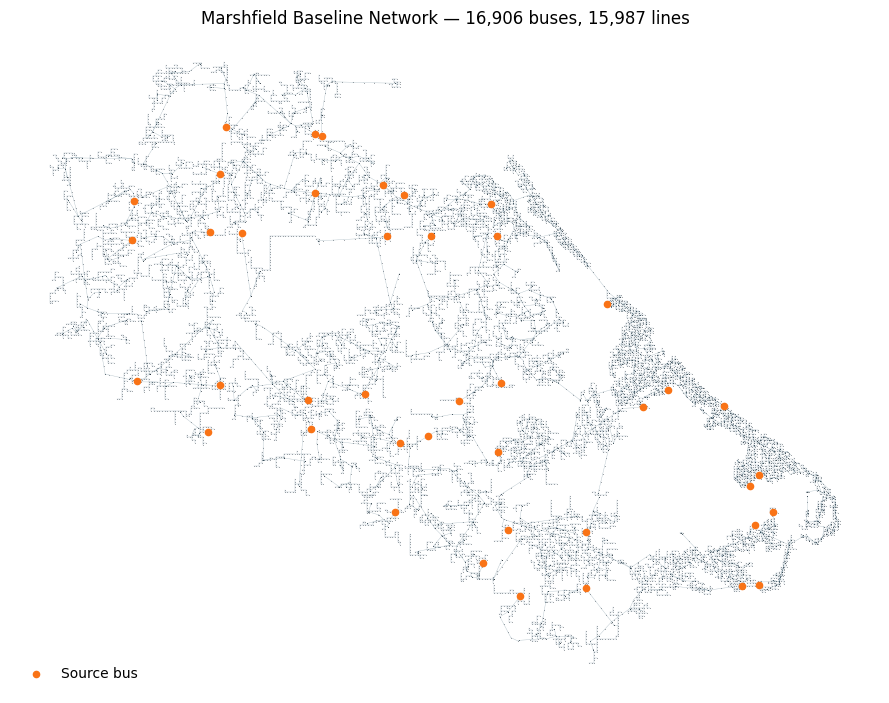

Saved: locations/marshfield/data/power_grid/figures/baseline_network.png


In [11]:
import matplotlib.pyplot as plt

buses = pd.read_csv(grid["asset_registry"] / "buses.csv")
lines = pd.read_csv(grid["asset_registry"] / "lines.csv")
sources = pd.read_csv(grid["asset_registry"] / "sources.csv")
source_buses = set(sources["bus"].dropna())

fig, ax = plt.subplots(figsize=(9, 9))

# Draw lines first so buses appear on top.
for _, row in lines.dropna(subset=["from_lon", "from_lat", "to_lon", "to_lat"]).iterrows():
    ax.plot([row.from_lon, row.to_lon], [row.from_lat, row.to_lat], c="#486b7d", lw=0.3, alpha=0.4)

non_source = buses[~buses["bus"].isin(source_buses)].dropna(subset=["lon", "lat"])
src = buses[buses["bus"].isin(source_buses)].dropna(subset=["lon", "lat"])
ax.scatter(non_source.lon, non_source.lat, s=0.5, c="#1f2933", alpha=0.3, linewidths=0)
ax.scatter(src.lon, src.lat, s=20, c="#f97316", zorder=5, label="Source bus")

ax.set_title(f"Marshfield Baseline Network — {len(buses):,} buses, {len(lines):,} lines")
ax.set_aspect("equal", adjustable="box")
ax.axis("off")
ax.legend(loc="lower left", frameon=False)
fig.tight_layout()

fig_path = grid["figures"] / "baseline_network.png"
fig_path.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(fig_path, dpi=150)
plt.show()
print(f"Saved: {fig_path.relative_to(repo_root)}")
